<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/ML-Project-Phase-5/Phase5_comparison_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 5

# Cell 1 — Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

SEED = 42
np.random.seed(SEED)
print("All imports successful.")
print(f"XGBoost version: {xgb.__version__}")

All imports successful.
XGBoost version: 3.2.0


# Cell 2 — Load data and build 5-class target (same as Phase 3)

In [3]:
# Load dataset
dataset  = fetch_ucirepo(id=601)
features = dataset.data.features
targets  = dataset.data.targets
df       = pd.concat([features, targets], axis=1)

# Build 6-class target using same priority rule as before
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

def assign_class(row):
    for idx, col in enumerate(failure_cols, start=1):
        if row[col] == 1:
            return idx
    return 0

df["target"] = df.apply(assign_class, axis=1)

# Drop RNF (class 5) — same decision as Phase 3 Experiment 1
df5 = df[df["target"] != 5].copy()

feature_cols = [
    "Air temperature", "Process temperature",
    "Rotational speed", "Torque", "Tool wear"
]

names_5 = ["No Failure", "TWF", "HDF", "PWF", "OSF"]

print(f"Samples after dropping RNF: {len(df5):,}")
print("\nClass distribution:")
dist = df5["target"].value_counts().sort_index()
for i, count in dist.items():
    print(f"  {names_5[i]:<12}  {count:>5}  ({100*count/len(df5):.2f}%)")

Samples after dropping RNF: 9,982

Class distribution:
  No Failure     9652  (96.69%)
  TWF              46  (0.46%)
  HDF             115  (1.15%)
  PWF              91  (0.91%)
  OSF              78  (0.78%)


# Cell 3 — Train/test split + preprocessing (identical to Phase 3 Exp 1)

In [4]:
X = df5[feature_cols].values
y = df5["target"].values

# Same 80/20 stratified split, same seed — fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# StandardScaler — fit on train only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE — same as Phase 3 Experiment 1
min_count = int(np.min(np.bincount(y_train)))
k = max(1, min(5, min_count - 1))
smote = SMOTE(random_state=SEED, k_neighbors=k)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f"Training samples after SMOTE : {X_train_res.shape[0]:,}")
print(f"Test samples                 : {X_test_sc.shape[0]:,}")
print(f"Features                     : {X_train_res.shape[1]}")

Training samples after SMOTE : 38,605
Test samples                 : 1,997
Features                     : 5


# Cell 4 — Train our best Phase 3 model (RF Experiment 1)

In [5]:
print("=" * 55)
print("MODEL A — Random Forest (our Phase 3 best model)")
print("=" * 55)

clf_rf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)
clf_rf.fit(X_train_res, y_train_res)

y_pred_rf = clf_rf.predict(X_test_sc)
y_prob_rf  = clf_rf.predict_proba(X_test_sc)

acc_rf    = accuracy_score(y_test, y_pred_rf)
bin_r_rf  = recall_score((y_test!=0).astype(int),
                          (y_pred_rf!=0).astype(int))
bin_p_rf  = precision_score((y_test!=0).astype(int),
                             (y_pred_rf!=0).astype(int))
bin_f1_rf = f1_score((y_test!=0).astype(int),
                      (y_pred_rf!=0).astype(int))
mac_f1_rf = f1_score(y_test, y_pred_rf,
                      average="macro", zero_division=0)

print(f"  Accuracy        : {acc_rf:.4f}")
print(f"  Binary Recall   : {bin_r_rf:.4f}  (failures caught)")
print(f"  Binary Precision: {bin_p_rf:.4f}")
print(f"  Binary F1       : {bin_f1_rf:.4f}")
print(f"  Macro F1        : {mac_f1_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=names_5, zero_division=0))

MODEL A — Random Forest (our Phase 3 best model)
  Accuracy        : 0.9664
  Binary Recall   : 0.8333  (failures caught)
  Binary Precision: 0.5046
  Binary F1       : 0.6286
  Macro F1        : 0.7035

              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1931
         TWF       0.07      0.33      0.12         9
         HDF       0.73      0.83      0.78        23
         PWF       0.89      0.89      0.89        18
         OSF       0.62      0.94      0.75        16

    accuracy                           0.97      1997
   macro avg       0.66      0.79      0.70      1997
weighted avg       0.98      0.97      0.97      1997



# Cell 5 — Train XGBoost (Phase 4 candidate)

In [6]:
print("=" * 55)
print("MODEL B — XGBoost (Phase 4 literature candidate)")
print("=" * 55)

# XGBoost multi-class — remap labels to 0-4 for XGBoost
# (y values are 0,1,2,3,4 already so no remapping needed)

clf_xgb = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    objective        = "multi:softmax",
    num_class        = 5,
    use_label_encoder= False,
    eval_metric      = "mlogloss",
    random_state     = SEED,
    n_jobs           = -1,
)
clf_xgb.fit(X_train_res, y_train_res)

y_pred_xgb = clf_xgb.predict(X_test_sc)
y_prob_xgb  = clf_xgb.predict_proba(X_test_sc)

acc_xgb    = accuracy_score(y_test, y_pred_xgb)
bin_r_xgb  = recall_score((y_test!=0).astype(int),
                           (y_pred_xgb!=0).astype(int))
bin_p_xgb  = precision_score((y_test!=0).astype(int),
                              (y_pred_xgb!=0).astype(int))
bin_f1_xgb = f1_score((y_test!=0).astype(int),
                       (y_pred_xgb!=0).astype(int))
mac_f1_xgb = f1_score(y_test, y_pred_xgb,
                       average="macro", zero_division=0)

print(f"  Accuracy        : {acc_xgb:.4f}")
print(f"  Binary Recall   : {bin_r_xgb:.4f}  (failures caught)")
print(f"  Binary Precision: {bin_p_xgb:.4f}")
print(f"  Binary F1       : {bin_f1_xgb:.4f}")
print(f"  Macro F1        : {mac_f1_xgb:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
      target_names=names_5, zero_division=0))

MODEL B — XGBoost (Phase 4 literature candidate)
  Accuracy        : 0.9750
  Binary Recall   : 0.8485  (failures caught)
  Binary Precision: 0.6087
  Binary F1       : 0.7089
  Macro F1        : 0.7223

              precision    recall  f1-score   support

  No Failure       0.99      0.98      0.99      1931
         TWF       0.03      0.11      0.05         9
         HDF       0.96      0.96      0.96        23
         PWF       0.94      0.89      0.91        18
         OSF       0.62      0.81      0.70        16

    accuracy                           0.97      1997
   macro avg       0.71      0.75      0.72      1997
weighted avg       0.99      0.97      0.98      1997



# Cell 6 — Side-by-side summary table

In [7]:
print("=" * 65)
print("PHASE 5 — HEAD-TO-HEAD COMPARISON SUMMARY")
print("=" * 65)
print(f"  {'Metric':<25}  {'Random Forest':>15}  {'XGBoost':>10}")
print("  " + "-" * 55)
print(f"  {'Accuracy':<25}  {acc_rf:>15.4f}  {acc_xgb:>10.4f}")
print(f"  {'Binary Recall':<25}  {bin_r_rf:>15.4f}  {bin_r_xgb:>10.4f}")
print(f"  {'Binary Precision':<25}  {bin_p_rf:>15.4f}  {bin_p_xgb:>10.4f}")
print(f"  {'Binary F1':<25}  {bin_f1_rf:>15.4f}  {bin_f1_xgb:>10.4f}")
print(f"  {'Macro F1':<25}  {mac_f1_rf:>15.4f}  {mac_f1_xgb:>10.4f}")
print("=" * 65)

# Per-class F1 comparison
print()
print("  Per-class F1 comparison:")
print(f"  {'Class':<15}  {'RF F1':>8}  {'XGB F1':>8}")
print("  " + "-" * 35)

from sklearn.metrics import f1_score as f1
for i, name in enumerate(names_5):
    rf_f1  = f1(y_test == i, y_pred_rf == i,
                 zero_division=0)
    xgb_f1 = f1(y_test == i, y_pred_xgb == i,
                 zero_division=0)
    winner = "RF ✓" if rf_f1 > xgb_f1 else ("XGB ✓" if xgb_f1 > rf_f1 else "Tie")
    print(f"  {name:<15}  {rf_f1:>8.4f}  {xgb_f1:>8.4f}  {winner}")

PHASE 5 — HEAD-TO-HEAD COMPARISON SUMMARY
  Metric                       Random Forest     XGBoost
  -------------------------------------------------------
  Accuracy                            0.9664      0.9750
  Binary Recall                       0.8333      0.8485
  Binary Precision                    0.5046      0.6087
  Binary F1                           0.6286      0.7089
  Macro F1                            0.7035      0.7223

  Per-class F1 comparison:
  Class               RF F1    XGB F1
  -----------------------------------
  No Failure         0.9830    0.9880  XGB ✓
  TWF                0.1200    0.0500  RF ✓
  HDF                0.7755    0.9565  XGB ✓
  PWF                0.8889    0.9143  XGB ✓
  OSF                0.7500    0.7027  RF ✓


# Cell 7 — Confusion matrices side by side

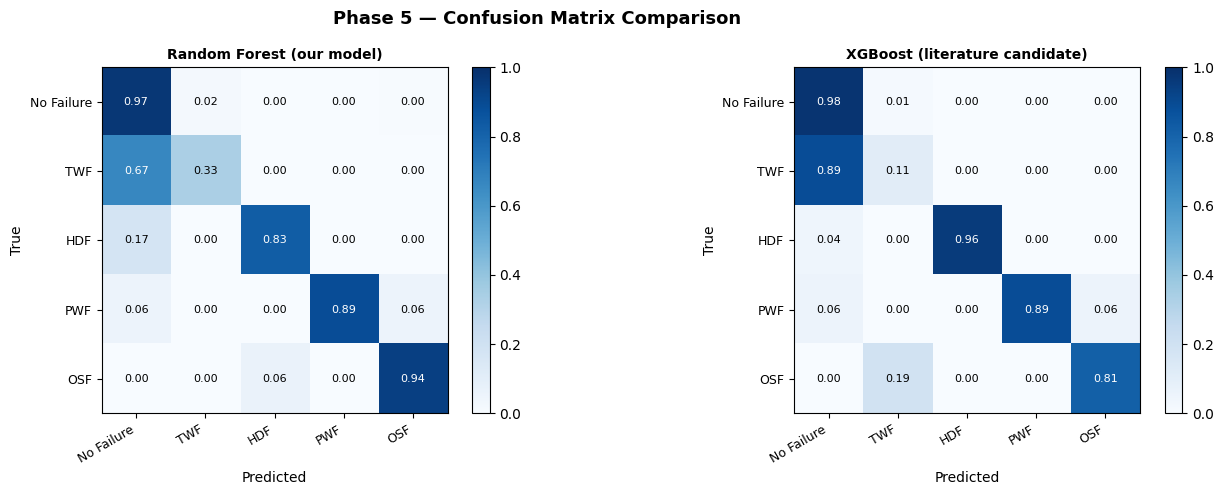

Confusion matrix saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 5 — Confusion Matrix Comparison",
             fontsize=13, fontweight="bold")

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ["Random Forest (our model)", "XGBoost (literature candidate)"]
):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(names_5, rotation=30, ha="right", fontsize=9)
    ax.set_yticklabels(names_5, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(5):
        for j in range(5):
            colour = "white" if cm_pct[i,j] > 0.5 else "black"
            ax.text(j, i, f"{cm_pct[i,j]:.2f}",
                    ha="center", va="center",
                    fontsize=8, color=colour)

plt.tight_layout()
plt.savefig("phase5_confusion_matrices.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")

# Cell 8 — ROC curves side by side

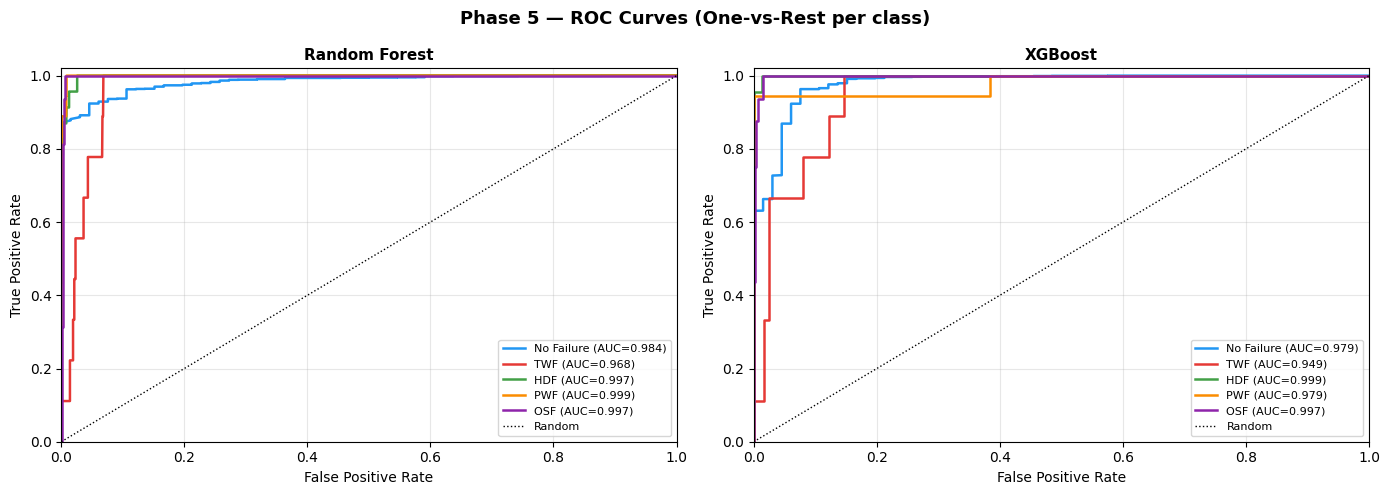

ROC curves saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 5 — ROC Curves (One-vs-Rest per class)",
             fontsize=13, fontweight="bold")

palette = ["#2196F3","#E53935","#43A047","#FB8C00","#8E24AA"]

for ax, y_prob, title in zip(
    axes,
    [y_prob_rf, y_prob_xgb],
    ["Random Forest", "XGBoost"]
):
    y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
    for i, (name, col) in enumerate(zip(names_5, palette)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=1.8,
                label=f"{name} (AUC={roc_auc:.3f})")
    ax.plot([0,1],[0,1],"k:",lw=1,label="Random")
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase5_roc_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("ROC curves saved.")

# Cell 9 — Feature importance comparison

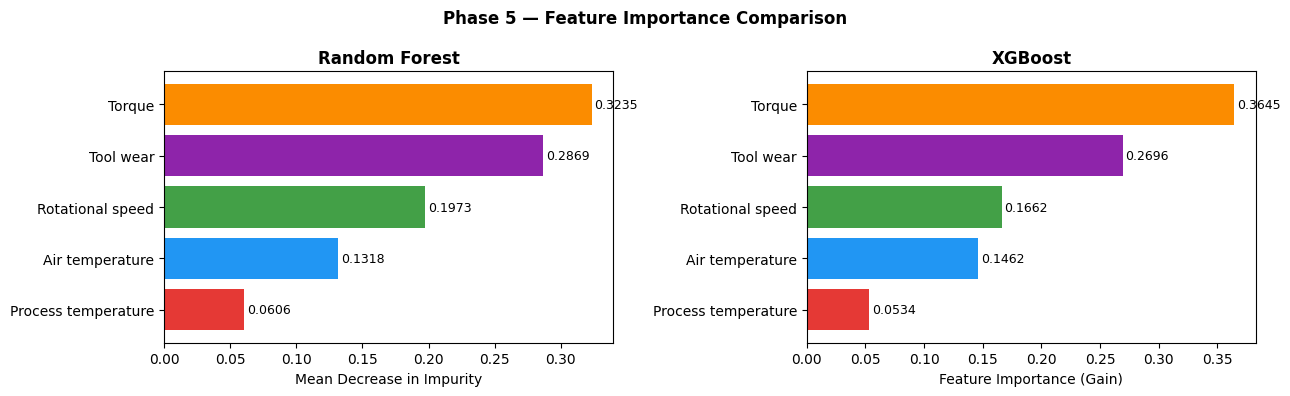

Feature importance plot saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Phase 5 — Feature Importance Comparison",
             fontsize=12, fontweight="bold")

colours = ["#2196F3","#E53935","#43A047","#FB8C00","#8E24AA"]

# Random Forest — MDI importance
rf_imp = clf_rf.feature_importances_
rf_idx = np.argsort(rf_imp)[::-1]
axes[0].barh([feature_cols[i] for i in rf_idx],
              rf_imp[rf_idx],
              color=[colours[i] for i in rf_idx])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest", fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity")
for bar, val in zip(axes[0].patches, rf_imp[rf_idx]):
    axes[0].text(val+0.002, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

# XGBoost — gain importance
xgb_imp = clf_xgb.feature_importances_
xgb_idx = np.argsort(xgb_imp)[::-1]
axes[1].barh([feature_cols[i] for i in xgb_idx],
              xgb_imp[xgb_idx],
              color=[colours[i] for i in xgb_idx])
axes[1].invert_yaxis()
axes[1].set_title("XGBoost", fontweight="bold")
axes[1].set_xlabel("Feature Importance (Gain)")
for bar, val in zip(axes[1].patches, xgb_imp[xgb_idx]):
    axes[1].text(val+0.002, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("phase5_feature_importance.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Feature importance plot saved.")